In [3]:
import numpy as np

real_eigenvalues = np.load("../result/PA/real_eigenvalues.npy")
percentile_eigenvalues = np.load("../result/PA/percentile_eigenvalues.npy")
n_factors_parallel = int(np.load("../result/PA/n_factors_parallel.npy")[0])
n_components = 182

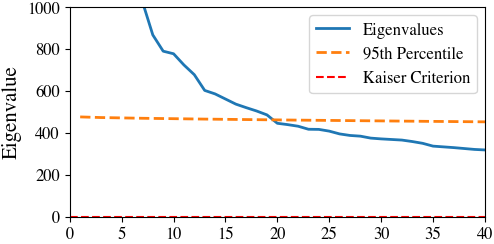

In [4]:
import sys, os
import matplotlib.pyplot as plt
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)
# --- 7. Generate the Final Scree Plot ---
plt.figure(figsize=(5, 2.5))
x_values = range(1, n_components + 1)

plt.plot(x_values, real_eigenvalues, '-', linewidth=2, label='Eigenvalues')
plt.plot(x_values, percentile_eigenvalues, '--', linewidth=2, label='95th Percentile')
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion')

# plt.title('Corrected Scree Plot (on Normalized Data)')
# plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue')
# plt.yscale('log')
# plt.grid()
plt.legend()
# Focus on the most important part of the plot
plt.xlim(0, 40)
# plt.ylim(0, max(real_eigenvalues[1:])*1.5) # Zoom in, ignoring the first factor for scale
plt.ylim(0, 1000)

# Save the plot
output_dir = "../result"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, "corrected_scree_plot.pdf"), bbox_inches='tight')
plt.show()

In [5]:
import pandas as pd

from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None)

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [9]:
# 1. Count the NaN values for each row (test-taker)
nan_counts = resmat.isnull().sum(axis=1)

# 2. Sort the results to find the test-takers with the least NaNs
sorted_nan_counts = nan_counts.sort_values()

# 3. Select the top 10 and print the result
top_10_with_least_nan = sorted_nan_counts.head(100)

with pd.option_context('display.max_rows', None):
  print(top_10_with_least_nan)

request.model
openai/gpt-3.5-turbo-0613                    2295
meta/llama-2-7b                              7280
mistralai/mistral-7b-v0.1                    7280
meta/llama-2-13b                             7280
meta/llama-2-70b                             7280
AlephAlpha/luminous-extended                18765
openai/text-davinci-002                     18765
openai/text-davinci-003                     18765
AlephAlpha/luminous-supreme                 18765
ai21/j2-grande                              18765
AlephAlpha/luminous-base                    18765
ai21/j2-jumbo                               18765
openai/gpt-3.5-turbo-0301                   20444
tiiuae/falcon-7b                            20503
meta/llama-65b                              20503
tiiuae/falcon-40b                           20503
openai/text-curie-001                       23691
openai/text-ada-001                         23691
openai/text-babbage-001                     23691
cohere/medium-20221108              

In [6]:
from helper import process_reference_composite
import numpy as np
from tqdm import tqdm

scenarios_testing = [['air_bench_2024'], ['math', 'gsm'], ['mmlu'], ['med_qa']]
bar_heights_convergent_list = []
bar_heights_divergent_list = []
line_values_convergent_list = []
line_values_divergent_list = []
for s in tqdm(scenarios_testing):
  print(s)
  results_check = process_reference_composite(resmat, theta_df, a_df, b_series, s)
  bar_heights_convergent_list.append(results_check['conv_corr'])
  bar_heights_divergent_list.append(results_check['div_corr'])
  line_values_convergent_list.append(results_check['conv_corr_mean'])
  line_values_divergent_list.append(results_check['div_corr_mean'])

bar_heights_convergent = np.absolute(bar_heights_convergent_list)
bar_heights_divergent = np.absolute(bar_heights_divergent_list)
line_values_convergent = np.absolute(line_values_convergent_list)
line_values_divergent = np.absolute(line_values_divergent_list)

  0%|          | 0/4 [00:00<?, ?it/s]

['air_bench_2024']
Mean unit vector:  [ 0.15788884  0.12192029 -0.20424938  0.14769147 -0.08909655  0.00674207
  0.13001913  0.38275072 -0.3342275  -0.27393126  0.03548491  0.25131562
 -0.28736213 -0.4951297   0.04810696  0.04254235  0.16937524  0.20083156
  0.27064428]
Mean unit vector:  [ 8.7650202e-02 -1.9348134e-01 -4.5048916e-03  3.0354402e-04
 -2.7384856e-01 -3.9389920e-01 -1.2806861e-01 -2.2029307e-01
  3.0856737e-01 -8.8170439e-02 -4.1135219e-01 -3.9413470e-01
 -1.6451129e-01 -1.1405341e-01  1.5675986e-01  1.0914784e-01
 -1.5494092e-02  3.2985809e-01  2.1595275e-01]
Used pre-computed direction vector. [ 8.3472341e-02 -1.9222133e-01 -2.7564226e-02  2.9497756e-02
 -2.8652298e-01 -3.8351992e-01 -1.0490729e-01 -2.0395660e-01
  2.7948627e-01 -7.9143204e-02 -4.0780070e-01 -3.9288455e-01
 -1.7605518e-01 -1.2034319e-01  1.8554886e-01  1.3114275e-01
  3.3247721e-04  3.5156754e-01  2.1662463e-01]
Used pre-computed direction vector. [ 0.09446862 -0.18845399 -0.01322626  0.00660722 -0.2779

 25%|██▌       | 1/4 [00:02<00:07,  2.44s/it]

div_corr -0.07372937112780306
conv_corr 0.9885017421602788
div_corr_mean -0.0762964761539245
conv_corr_mean 0.9885017421602788
['math', 'gsm']


 50%|█████     | 2/4 [00:04<00:04,  2.26s/it]

Mean unit vector:  [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
Mean unit vector:  [-0.21494706 -0.22744916 -0.23566988 -0.1679211  -0.3850087  -0.2394518
  0.04993943  0.25944665 -0.39451882 -0.04396391 -0.01316161 -0.33871678
  0.30975133  0.06780565  0.26811373 -0.26613766  0.13065511 -0.04555357
 -0.08982014]
Used pre-computed direction vector. [-0.22217683 -0.23732743 -0.24023862 -0.1697346  -0.37846613 -0.24225266
  0.06519122  0.26698127 -0.39838114 -0.05022392 -0.01661013 -0.32513592
  0.30071217  0.06421725  0.2603656  -0.2678348   0.1399193  -0.03747842
 -0.08976768]
Used pre-computed direction vector. [-0.2121759  -0.22592627 -0.2385837  -0.16556206 -0.3867546  -0.24016796
  0.05153811  0.26446506 -0.3984767  -0.04828941 -0.01366189 -0.3356655
  0.30475757  0.05998956  0.26903284 -0.26501375

 75%|███████▌  | 3/4 [00:06<00:02,  2.12s/it]

div_corr -0.23693341583576796
conv_corr 0.9020015944762607
div_corr_mean -0.2187698260399615
conv_corr_mean 0.9786817105932852
['med_qa']


100%|██████████| 4/4 [00:08<00:00,  2.08s/it]

Mean unit vector:  [ 0.17750438  0.09307601 -0.20640169  0.14724277 -0.12474029 -0.05205568
  0.11325733  0.3372349  -0.2763865  -0.2841941  -0.03823017  0.19182554
 -0.32208386 -0.5072406   0.0670848   0.0680073   0.16385606  0.2590437
  0.30199188]
Mean unit vector:  [-0.17347513 -0.1367835   0.04039681  0.02793326 -0.40603727 -0.2902918
 -0.17594741  0.33981892 -0.23942335 -0.19164811  0.16557115 -0.25067896
  0.24668725 -0.30063593  0.28633356 -0.26476938  0.12047154 -0.08473967
  0.20949413]
Used pre-computed direction vector. [ 0.38742042  0.234502   -0.0939404   0.01635498  0.2590883   0.13689576
  0.29210606 -0.2608264   0.19489136  0.25366813 -0.08914094  0.21986881
 -0.35090986  0.10027138 -0.23608606  0.42798606  0.07838911  0.013649
 -0.09771319]
Used pre-computed direction vector. [-0.24147688 -0.17488514  0.11086338 -0.01930871 -0.38641304 -0.28854904
 -0.22281757  0.24633412 -0.16072151 -0.10781363  0.18705648 -0.32753897
  0.36644518 -0.14879507  0.27940556 -0.30140164 

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_39287/1848551729.py:50: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


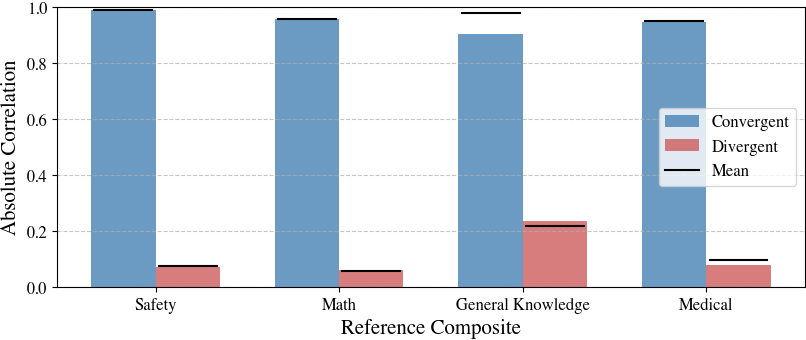

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import os, sys
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

# Sample data
categories = ['Safety', 'Math', 'General Knowledge', 'Medical']

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
rects1 = ax.bar(x - width/2, bar_heights_convergent, width, label='Convergent', color='steelblue', alpha=0.8)
rects2 = ax.bar(x + width/2, bar_heights_divergent, width, label='Divergent', color='indianred', alpha=0.8)

# --- Function to add horizontal line markers ---
def add_line_markers(rects, second_values, protrusion_amount=-0.05):
    
    for i, rect in enumerate(rects):
        y_value = second_values[i]
        
        # --- MODIFICATION ---
        # To protrude left, subtract from the bar's starting x-position.
        x_start = rect.get_x() - rect.get_width() * protrusion_amount
        
        # To protrude right, add the bar's width PLUS the protrusion amount.
        x_end = rect.get_x() + rect.get_width() * (1 + protrusion_amount)
        
        # Plot the horizontal line
        ax.plot([x_start, x_end], [y_value, y_value], color='black', linewidth=1.5)

add_line_markers(rects1, line_values_convergent)
add_line_markers(rects2, line_values_divergent)
# --- MODIFICATION: Create and place the legend at the top ---
handles, labels = ax.get_legend_handles_labels()
mean_line_handle = Line2D([0], [0], color='black', linewidth=1.5, label='Mean')
handles.append(mean_line_handle)
# Add some text for labels, title and axes ticks
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('Reference Composite')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(handles=handles, frameon=True, loc='center right',  fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig('../result/selective_scale_correlations.pdf', bbox_inches='tight')
fig.tight_layout()
plt.show()

MIRT AUC: 0.89363 ± 0.00052


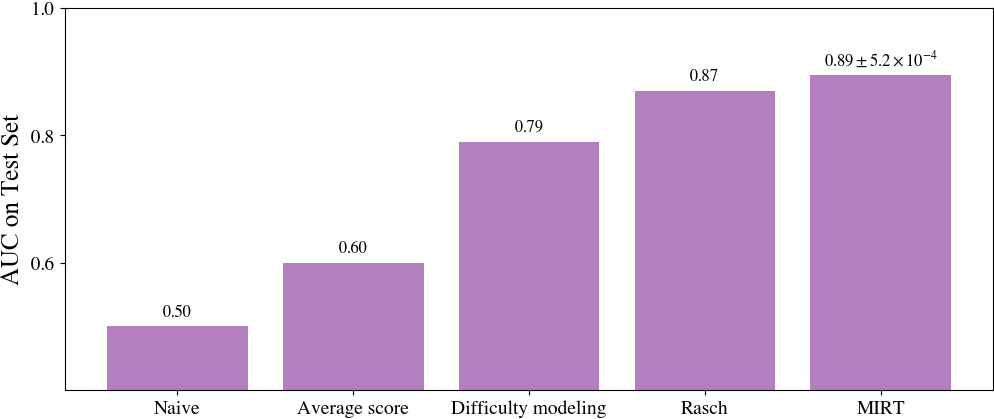

In [8]:
import sys
import matplotlib.pyplot as plt
sys.path.append('..') 
import style
mirt_runs = [0.893350791, 0.893389648, 0.893980013, 0.894449958, 0.892994953]
import numpy as np
mean_mirt = np.mean(mirt_runs)
std_mirt = np.std(mirt_runs)

print(f"MIRT AUC: {mean_mirt:.5f} ± {std_mirt:.5f}")

plt.rcParams.update(style.rcparams)
values = [0.5, 0.6, 0.79, 0.87, mean_mirt]
labels = ['Naive', 'Average score', 'Difficulty modeling', 'Rasch', 'MIRT']

fig, ax = plt.subplots(figsize=(10, 4.25))
bars = ax.bar(labels, values, color='#b37fbf')

# ax.set_xlabel(r'Response Model', fontsize=15)
ax.set_ylabel(r'AUC on Test Set', fontsize=18)
ax.set_ylim(0.4, 1)
ax.set_yticks([i/5 for i in range(3, 6)])
# ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tick_params(axis="both", labelsize=14)

for i, (bar, v) in enumerate(zip(bars, values)):
    if labels[i] == 'MIRT':
        label_text = r'$0.89\pm5.2\times 10^{-4}$'
    else:
        label_text = f'{v:.2f}'
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, label_text, color='black',
            ha='center', va='bottom', fontsize=12)

plt.savefig("../result/test_auc_grow.pdf", bbox_inches="tight")
plt.show()